# 7문항 EDA — 지금 홈페이지가 쓰는 문항들

`https://p3.sumzip.com` 의 진단은 **7개 문항**으로 돌아간다(`v1.0.0` · `qs-v1.0.0`).
38개 설명변수 중 후진 제거로 살아남은 것들이다.

이 노트북은 **그 7개만** 파고든다.

1. 각 문항이 어떻게 응답되었나 — 분포와 결측
2. 각 문항이 돌봄부담과 어떤 관계인가
3. **문항끼리 겹치는가** — 상관관계 7×7
4. 어느 문항이 판정을 좌우하나 — 설명력과 모델 계수

## 실행 방법

```bash
cd ~/project2608
uv run --with jupyter --with pandas --with matplotlib --with scikit-learn \
       --with scipy --with pymysql jupyter lab
```

접속 정보는 프로젝트 루트의 `.env` 에서 읽는다.

## 안전

- **DB 는 읽기만 한다** (`v_cb_tree_v1` 조회)
- **`models/` 를 건드리지 않는다** — 가동 중인 홈페이지에 영향 없음
- **test 602건을 쓰지 않는다** — train 2,398건만

## 1. 준비

In [1]:
import os, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

def load_env():
    for d in (ROOT, *ROOT.parents):
        p = d / '.env'
        if p.is_file():
            for line in p.read_text(encoding='utf-8').splitlines():
                line = line.strip()
                if line and not line.startswith('#') and '=' in line:
                    k, v = line.split('=', 1)
                    os.environ.setdefault(k.strip(), v.strip().strip('\'"'))
            return p
print('.env :', load_env())

import numpy as np, pandas as pd, pymysql
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency, spearmanr

_inst = {f.name for f in font_manager.fontManager.ttflist}
for c in ['AppleGothic','Apple SD Gothic Neo','NanumGothic','Malgun Gothic']:
    if c in _inst: mpl.rcParams['font.family'] = c; break
mpl.rcParams['axes.unicode_minus'] = False

# 부담 5구간 — 단일 색상 순차 램프(진할수록 고부담). 1=최고부담
BURDEN = {1:'#801e1e',2:'#a92e2d',3:'#d04442',4:'#dd7170',5:'#e99b9a'}
NAME   = {1:'최고부담군',2:'고부담군',3:'중간부담군',4:'저부담군',5:'부담 없음'}
CAT1, CAT2, CAT3 = '#2a78d6', '#eb6834', '#8a8a86'
SEQ = ['#f2f0ec','#cfd9e8','#9db6d8','#5f8ac4','#2a78d6','#1c5cab']
SURFACE, INK1, INK2, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#e6e5e1', '#c8c7c2'
mpl.rcParams.update({'figure.facecolor':SURFACE,'axes.facecolor':SURFACE,'savefig.facecolor':SURFACE,
                     'figure.dpi':110,'font.size':10,'axes.titlesize':12,'axes.titleweight':'bold',
                     'axes.titlecolor':INK1,'axes.labelcolor':INK2,'text.color':INK1,
                     'xtick.color':INK2,'ytick.color':INK2})
def style(ax, grid='y'):
    ax.set_axisbelow(True)
    if grid: ax.grid(axis=grid, color=GRID, lw=0.8, zorder=0)
    for s in ('top','right'): ax.spines[s].set_visible(False)
    for s in ('left','bottom'): ax.spines[s].set_color(AXIS); ax.spines[s].set_linewidth(0.8)
    ax.tick_params(length=0); return ax
def wrap(s, n=7, cap=21):
    s = str(s); return '\n'.join(s[i:i+n] for i in range(0, min(len(s), cap), n))
print('준비 완료')

.env : /Users/pioneer3/project2608/.env


준비 완료


## 2. 7문항이 무엇인가

가동 중인 모델의 산출물에서 직접 읽는다. 목록을 손으로 적지 않는 이유는, 모델이 바뀌면
이 노트북도 자동으로 따라가야 하기 때문이다.

In [2]:
model = json.loads((ROOT/'models'/'model_v1.json').read_text(encoding='utf-8'))
qs    = json.loads((ROOT/'models'/'questions_v1.json').read_text(encoding='utf-8'))
F = model['features']
print(f"모델 {model['model_version']} · 문항집합 {model['question_set_version']} · {len(F)}문항\n")

qmap = {q['feature']: q for q in qs['questions']}
info = pd.DataFrame([{
    '번호': qmap[f]['questionNo'], '원문항': qmap[f]['originalItem'], 'feature': f,
    '화면 문항': qmap[f]['text'], '선택지': len(qmap[f].get('options') or []),
    '해당없음': '있음' if qmap[f].get('hasNotApplicable') else '',
} for f in F]).sort_values('번호').set_index('번호')
display(info)

모델 v1.0.0 · 문항집합 qs-v1.0.0 · 7문항



,원문항,feature,화면 문항,선택지,해당없음
번호,,,,,
1,G8,daily_routine_satisfaction,당사자는 요즘 하루하루의 일과를 어떻게 느끼고 있나요?,5,
2,F5,family_support_for_employment,당사자의 취업에 대해 가족들이 어느 정도 지지하고 있나요?,5,
3,G6,help_needed_hours,돌보고 계신 당사자에게 하루 중 어느 정도의 도움이 필요한가요?,5,
4,I4,household_head_type,가구의 생계를 주로 책임지는 분은 누구인가요?,8,
5,E4,last_job_quit_reason,(일을 그만둔 적이 있다면) 마지막 일자리를 그만둔 가장 큰 이유는 무엇인가요?,16,있음
6,A1,relation_to_person,응답하시는 분은 당사자와 어떤 관계인가요?,8,
7,F1,understands_work_meaning,"당사자는 ""일을 한다""는 것의 의미를 어느 정도 이해하고 있나요?",4,


## 3. 데이터 적재

In [3]:
con = pymysql.connect(host=os.environ['DB_HOST'], port=int(os.environ['DB_PORT']),
                      user=os.environ['DB_USER'], password=os.environ['DB_PASSWORD'],
                      database=os.environ['DB_NAME'], charset='utf8mb4')
meta = pd.read_sql("SELECT feature, var_scale, n_levels, scale_note FROM cb_feature_meta_v1", con)
cols = ', '.join(f'`{f}`' for f in F)
df = pd.read_sql(f"SELECT care_burden, {cols} FROM v_cb_tree_v1 WHERE split='train' ORDER BY row_id", con)
con.close()
meta = meta[meta['feature'].isin(F)].set_index('feature')
KO  = {f: qmap[f]['text'][:22] for f in F}
LBL = {f: {o['value']: o['label'] for o in (qmap[f].get('options') or [])} for f in F}
short = {**{f: f"{qmap[f]['questionNo']}. {KO[f][:16]}" for f in F}, 'care_burden': '★ 돌봄부담(target)'}

print(f'train {len(df):,}건 · 문항 {len(F)}개\n')
print('결측률 (%) — 결측은 누락이 아니라 분기 문항의 "해당 없음" 이다')
miss = (df[F].isna().mean()*100).round(1).sort_values(ascending=False)
for f, v in miss.items():
    print(f'  {f:32s} {v:5.1f}   ({meta.loc[f,"var_scale"]}, {int(meta.loc[f,"n_levels"])}레벨)')

train 2,398건 · 문항 7개

결측률 (%) — 결측은 누락이 아니라 분기 문항의 "해당 없음" 이다
  last_job_quit_reason              88.2   (nominal, 15레벨)
  daily_routine_satisfaction         0.1   (ordinal, 5레벨)
  family_support_for_employment      0.1   (ordinal, 5레벨)
  help_needed_hours                  0.0   (ordinal, 5레벨)
  household_head_type                0.0   (nominal, 8레벨)
  relation_to_person                 0.0   (nominal, 8레벨)
  understands_work_meaning           0.0   (ordinal, 4레벨)


/var/folders/q6/tjwyx9fx6rzd750055qzmw9h0000gs/T/ipykernel_23906/4268436594.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  meta = pd.read_sql("SELECT feature, var_scale, n_levels, scale_note FROM cb_feature_meta_v1", con)
/var/folders/q6/tjwyx9fx6rzd750055qzmw9h0000gs/T/ipykernel_23906/4268436594.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT care_burden, {cols} FROM v_cb_tree_v1 WHERE split='train' ORDER BY row_id", con)


## 4. 문항별 응답 분포

보호자가 실제로 어느 선택지를 골랐는지 본다. 한쪽으로 쏠린 문항은 판정에 기여할 여지가 작다.

findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


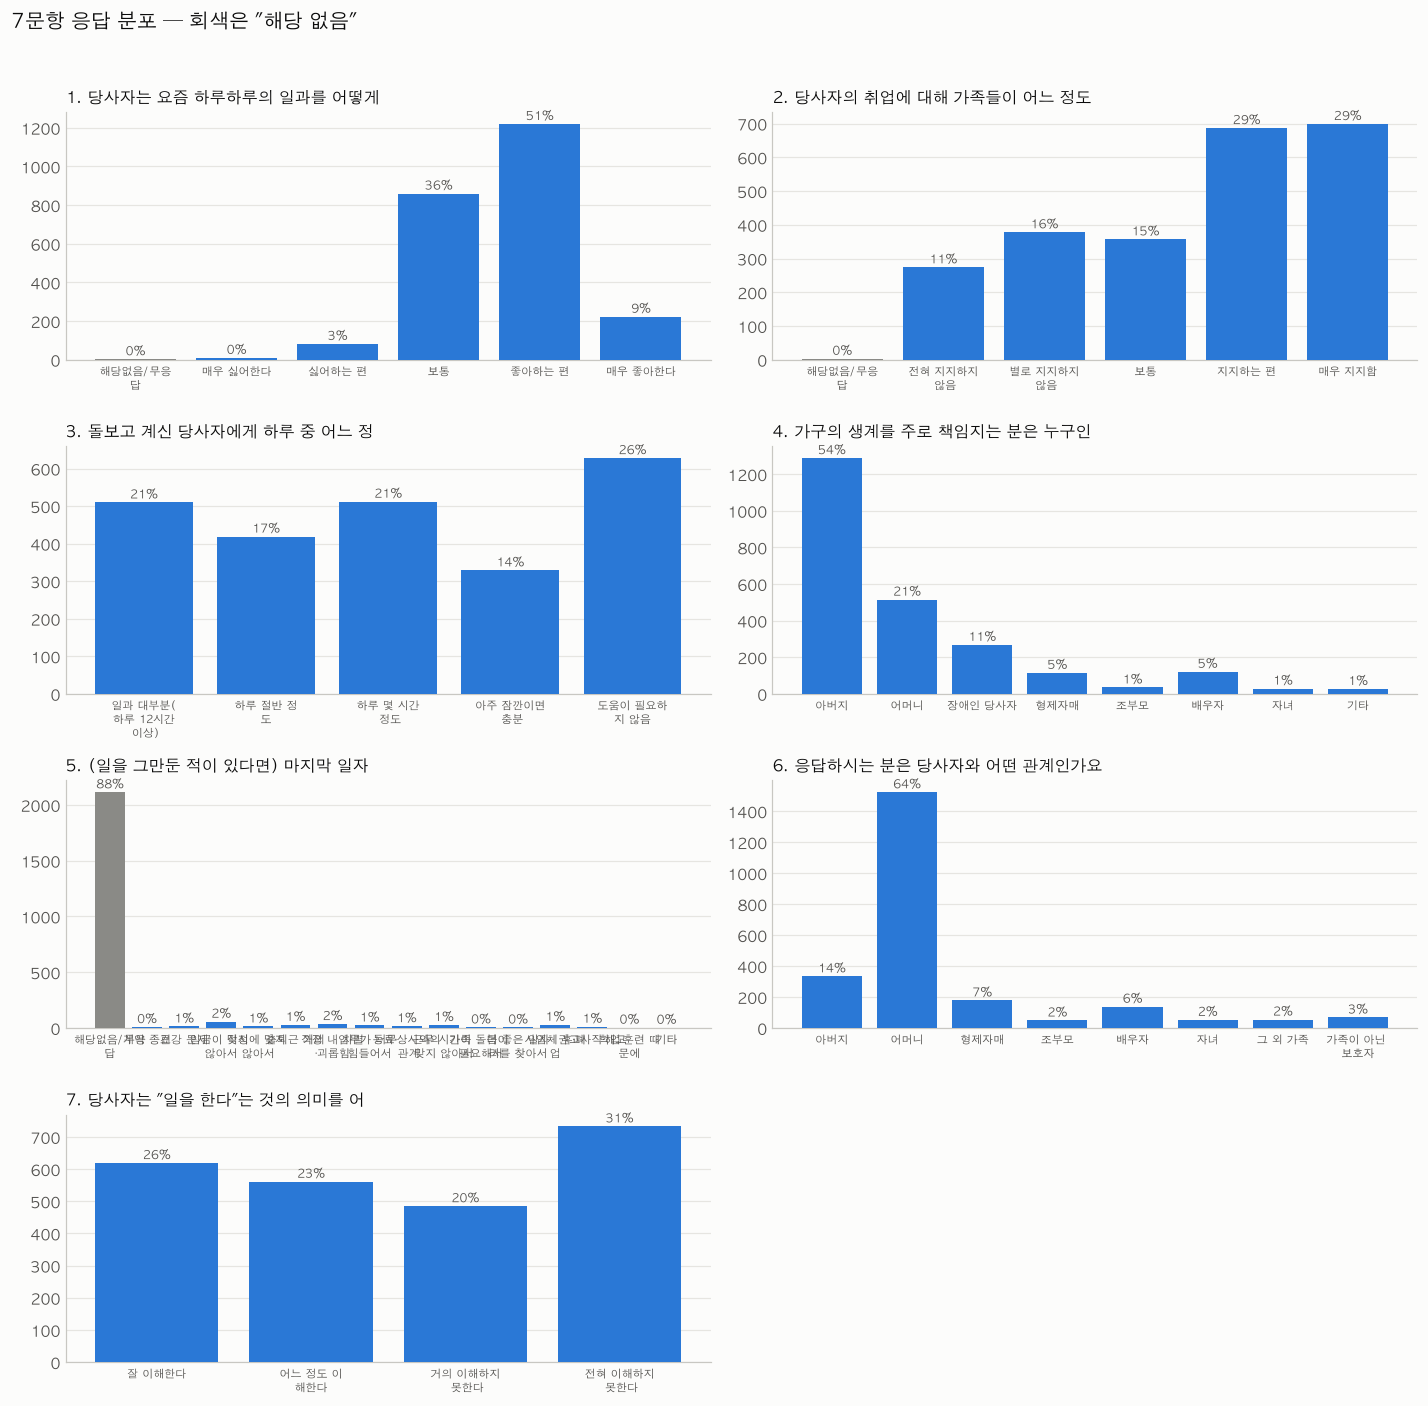

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(13, 13))
for ax, f in zip(axes.ravel(), F):
    style(ax)
    vc = df[f].value_counts(dropna=False)
    vc = vc.reindex(sorted(vc.index, key=lambda x: -999 if pd.isna(x) else x))
    labs = ['해당없음/무응답' if pd.isna(k) else str(LBL[f].get(int(k), int(k))) for k in vc.index]
    colr = [CAT3 if l.startswith('해당없음') else CAT1 for l in labs]
    ax.bar(range(len(vc)), vc.values, color=colr, zorder=3)
    for i, v in enumerate(vc.values):
        ax.annotate(f'{v/len(df)*100:.0f}%', (i, v), ha='center', va='bottom', fontsize=8, color=INK2)
    ax.set_xticks(range(len(labs))); ax.set_xticklabels([wrap(l) for l in labs], fontsize=7.4)
    ax.set_title(f"{qmap[f]['questionNo']}. {KO[f]}", loc='left', fontsize=10.5)
axes.ravel()[-1].axis('off')
fig.suptitle('7문항 응답 분포 — 회색은 "해당 없음"', x=0.005, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.965]); plt.show()

## 5. 각 문항과 돌봄부담의 관계

**핵심 그림이다.** 선택지별로 고부담군(1~2단계) 비율이 어떻게 달라지는지 본다.
막대가 계단처럼 기울면 그 문항이 부담을 가른다는 뜻이고, 평평하면 관계가 약하다.
표본 20건 미만 구간은 제외했다.

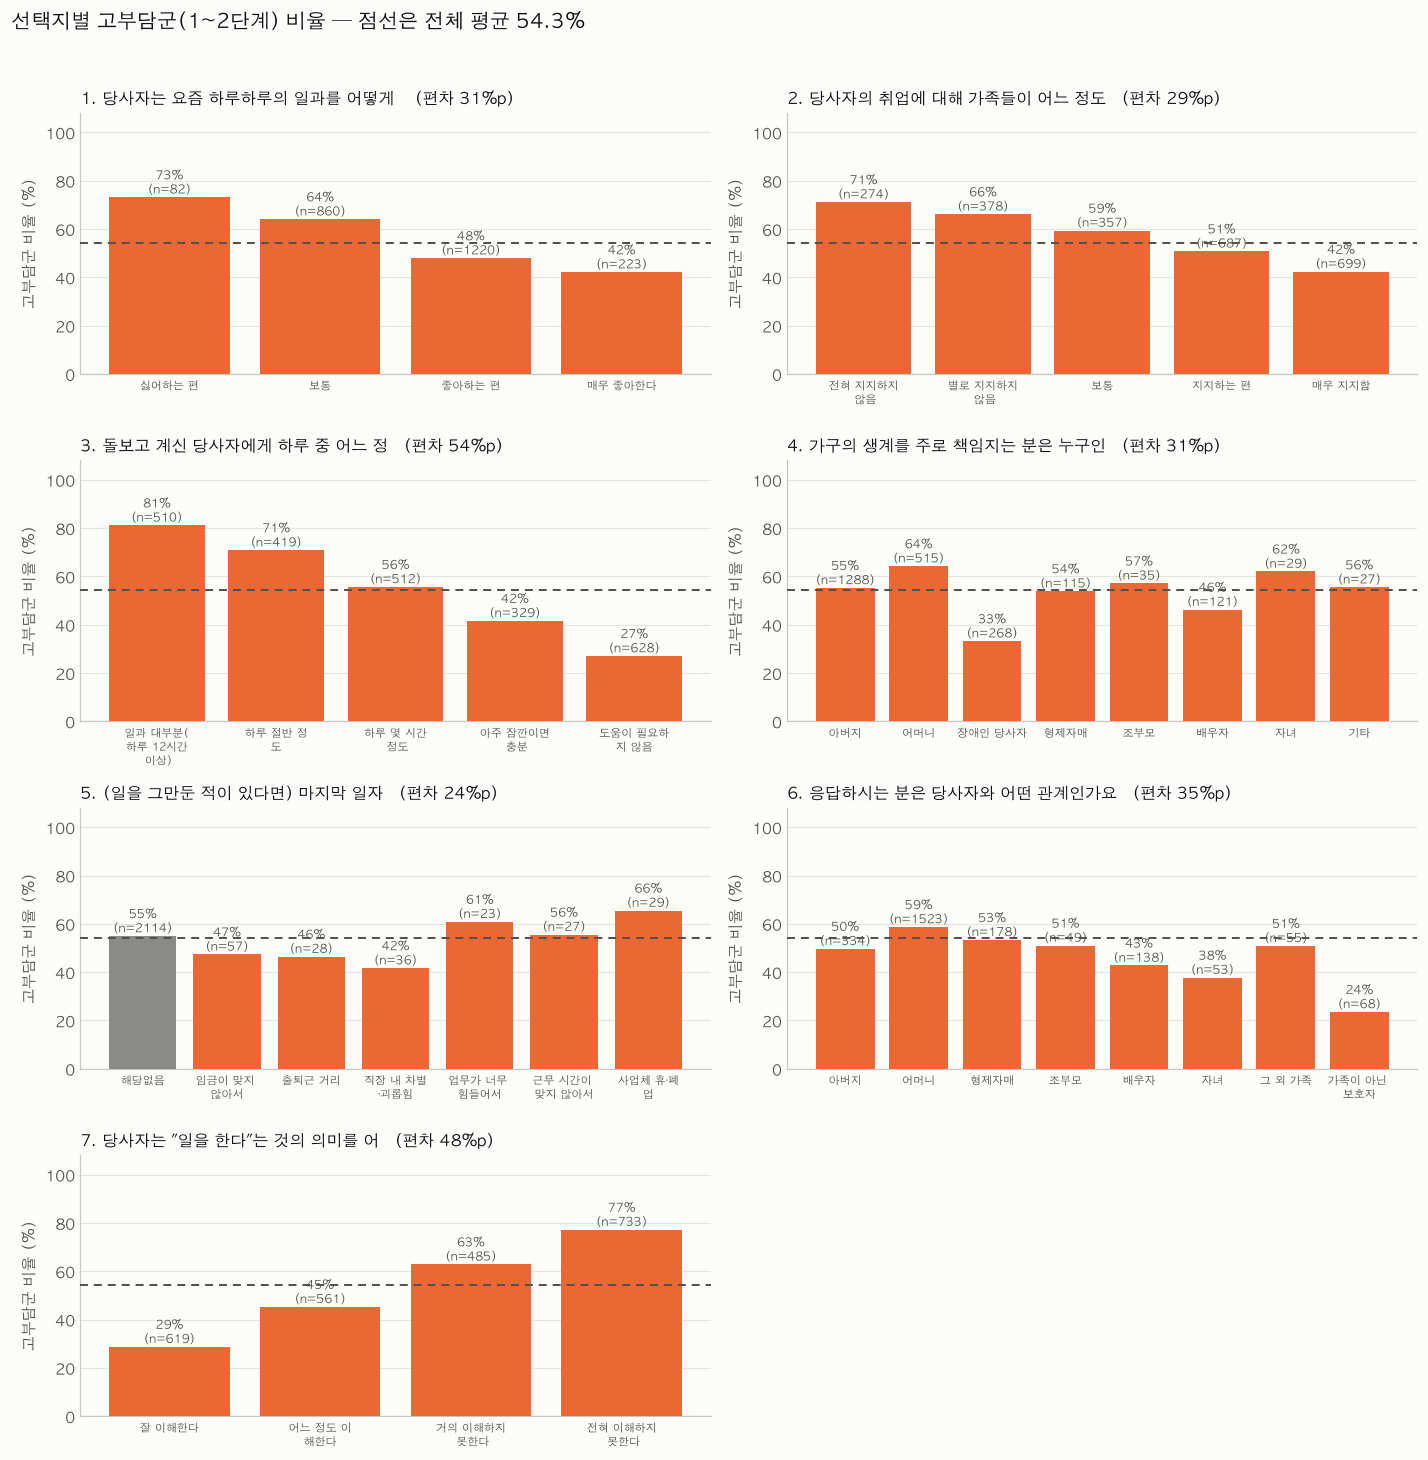

In [5]:
base = (df['care_burden'] <= 2).mean() * 100
fig, axes = plt.subplots(4, 2, figsize=(13, 13.5))
for ax, f in zip(axes.ravel(), F):
    style(ax)
    g = df.copy(); g['_k'] = g[f].fillna(-999)
    agg = g.groupby('_k').agg(n=('care_burden','size'),
                              hi=('care_burden', lambda s: (s<=2).mean()*100))
    agg = agg[agg['n'] >= 20]
    labs = ['해당없음' if k == -999 else str(LBL[f].get(int(k), int(k))) for k in agg.index]
    ax.bar(range(len(agg)), agg['hi'],
           color=[CAT3 if l == '해당없음' else CAT2 for l in labs], zorder=3)
    ax.axhline(base, color=INK2, lw=1.3, ls=(0,(4,3)), zorder=4)
    for i, (v, n) in enumerate(zip(agg['hi'], agg['n'])):
        ax.annotate(f'{v:.0f}%\n(n={n})', (i, v), ha='center', va='bottom', fontsize=7.6, color=INK2)
    ax.set_xticks(range(len(labs))); ax.set_xticklabels([wrap(l) for l in labs], fontsize=7.4)
    ax.set_ylim(0, 108); ax.set_ylabel('고부담군 비율 (%)')
    ax.set_title(f"{qmap[f]['questionNo']}. {KO[f]}   (편차 {agg['hi'].max()-agg['hi'].min():.0f}%p)",
                 loc='left', fontsize=10.5)
axes.ravel()[-1].axis('off')
fig.suptitle(f'선택지별 고부담군(1~2단계) 비율 — 점선은 전체 평균 {base:.1f}%',
             x=0.005, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.965]); plt.show()

## 6. 문항끼리 겹치는가 — 상관관계

문항 유형이 섞여 있어(순서형·명목형) 피어슨 상관은 쓸 수 없다.
**Cramér's V** 를 쓴다. 범주형 두 변수의 연관 강도를 0~1 로 나타내며 명목형에도 쓸 수 있다.

| Cramér's V | 해석 |
|---|---|
| 0.5 이상 | 강하게 겹친다. 한쪽을 빼도 될 수 있다 |
| 0.3 ~ 0.5 | 중간 |
| 0.1 ~ 0.3 | 약함 |
| 0.1 미만 | 사실상 무관 |

,1. 당사자는 요즘 하루하루의 일과,2. 당사자의 취업에 대해 가족들이,3. 돌보고 계신 당사자에게 하루,4. 가구의 생계를 주로 책임지는,5. (일을 그만둔 적이 있다면),6. 응답하시는 분은 당사자와 어떤,"7. 당사자는 ""일을 한다""는 것의",★ 돌봄부담(target)
1. 당사자는 요즘 하루하루의 일과,1.000,0.219,0.120,0.078,0.000,0.067,0.176,0.155
2. 당사자의 취업에 대해 가족들이,0.219,1.000,0.197,0.148,0.061,0.139,0.298,0.163
3. 돌보고 계신 당사자에게 하루,0.120,0.197,1.000,0.108,0.056,0.074,0.401,0.234
4. 가구의 생계를 주로 책임지는,0.078,0.148,0.108,1.000,0.089,0.605,0.104,0.091
5. (일을 그만둔 적이 있다면),0.000,0.061,0.056,0.089,1.000,0.079,0.101,0.035
6. 응답하시는 분은 당사자와 어떤,0.067,0.139,0.074,0.605,0.079,1.000,0.081,0.070
"7. 당사자는 ""일을 한다""는 것의",0.176,0.298,0.401,0.104,0.101,0.081,1.000,0.270
★ 돌봄부담(target),0.155,0.163,0.234,0.091,0.035,0.070,0.270,1.000


findfont: Failed to find font weight bold, now using 400.


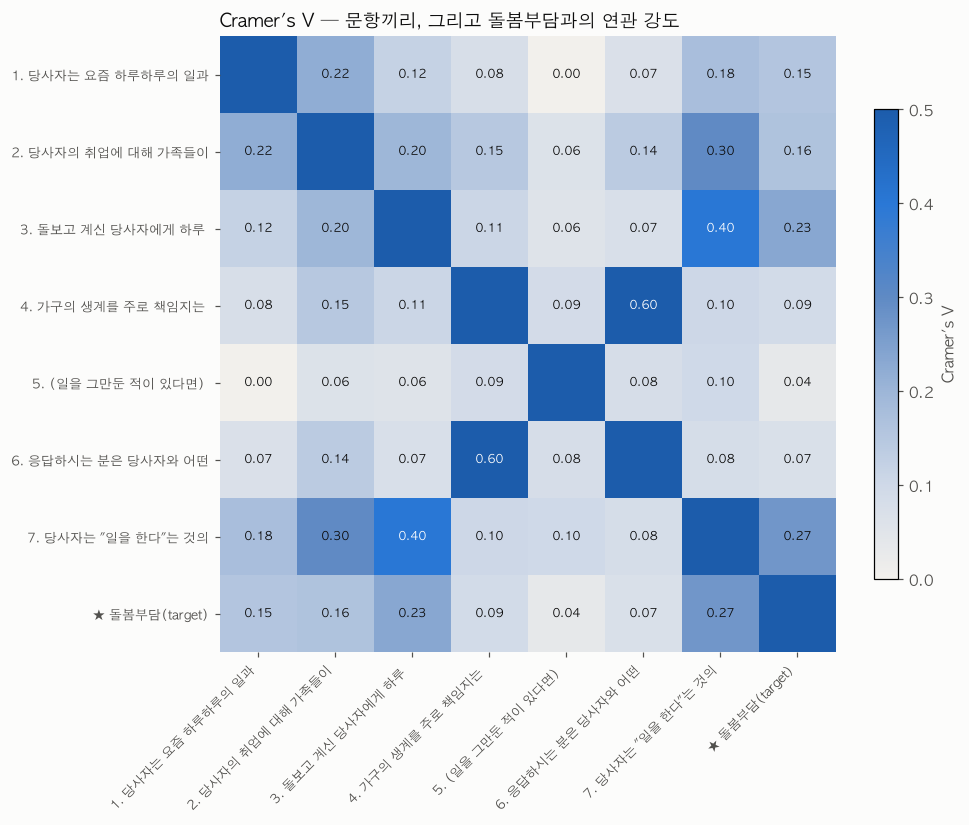

문항끼리 가장 많이 겹치는 5쌍:
  0.605   6. 응답하시는 분은 당사자와 어떤  ↔  4. 가구의 생계를 주로 책임지는 
  0.401   3. 돌보고 계신 당사자에게 하루   ↔  7. 당사자는 "일을 한다"는 것의
  0.298   2. 당사자의 취업에 대해 가족들이  ↔  7. 당사자는 "일을 한다"는 것의
  0.219   1. 당사자는 요즘 하루하루의 일과  ↔  2. 당사자의 취업에 대해 가족들이
  0.197   2. 당사자의 취업에 대해 가족들이  ↔  3. 돌보고 계신 당사자에게 하루 

돌봄부담과의 연관 (내림차순):
  0.270   7. 당사자는 "일을 한다"는 것의
  0.234   3. 돌보고 계신 당사자에게 하루 
  0.163   2. 당사자의 취업에 대해 가족들이
  0.155   1. 당사자는 요즘 하루하루의 일과
  0.091   4. 가구의 생계를 주로 책임지는 
  0.070   6. 응답하시는 분은 당사자와 어떤
  0.035   5. (일을 그만둔 적이 있다면) 


In [6]:
def cramers_v(a, b):
    # 편향 보정 Cramer's V. 결측은 하나의 범주(-999)로 취급한다.
    x = a.fillna(-999).astype(int); y = b.fillna(-999).astype(int)
    ct = pd.crosstab(x, y)
    if ct.shape[0] < 2 or ct.shape[1] < 2: return np.nan
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum(); phi2 = chi2 / n
    r, k = ct.shape
    phi2c = max(0.0, phi2 - (k-1)*(r-1)/(n-1))
    rc = r - (r-1)**2/(n-1); kc = k - (k-1)**2/(n-1)
    d = min(kc-1, rc-1)
    return float(np.sqrt(phi2c/d)) if d > 0 else np.nan

cols_all = F + ['care_burden']
V = pd.DataFrame(np.eye(len(cols_all)), index=cols_all, columns=cols_all)
for i, a in enumerate(cols_all):
    for b in cols_all[i+1:]:
        v = cramers_v(df[a], df[b]); V.loc[a,b] = V.loc[b,a] = v
Vs = V.rename(index=short, columns=short)
display(Vs.round(3))

cmap = LinearSegmentedColormap.from_list('seq', SEQ)
fig, ax = plt.subplots(figsize=(9.2, 7.8))
im = ax.imshow(Vs.values, cmap=cmap, vmin=0, vmax=0.5)
ax.set_xticks(range(len(Vs))); ax.set_xticklabels(Vs.columns, rotation=45, ha='right', fontsize=8.4)
ax.set_yticks(range(len(Vs))); ax.set_yticklabels(Vs.index, fontsize=8.4)
for i in range(len(Vs)):
    for j in range(len(Vs)):
        v = Vs.values[i,j]
        if i != j and not np.isnan(v):
            ax.annotate(f'{v:.2f}', (j,i), ha='center', va='center', fontsize=7.6,
                        color='white' if v > 0.3 else INK1)
ax.set_title("Cramer's V — 문항끼리, 그리고 돌봄부담과의 연관 강도", loc='left')
fig.colorbar(im, ax=ax, shrink=0.7, label="Cramer's V")
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()

pair = V.loc[F,F].where(~np.eye(len(F), dtype=bool)).stack().sort_values(ascending=False)
seen, out = set(), []
for (a,b), v in pair.items():
    if (b,a) in seen: continue
    seen.add((a,b)); out.append((a,b,v))
print('문항끼리 가장 많이 겹치는 5쌍:')
for a,b,v in out[:5]:
    print(f"  {v:.3f}   {short[a]}  ↔  {short[b]}")
print('\n돌봄부담과의 연관 (내림차순):')
for f, v in V.loc[F,'care_burden'].sort_values(ascending=False).items():
    print(f"  {v:.3f}   {short[f]}")

## 7. 순서형 문항만 — 스피어만 상관

순서가 있는 척도끼리는 **방향까지** 볼 수 있다.

`care_burden` 은 **1이 최고부담**이므로 부호를 거꾸로 읽어야 한다 —
양의 상관은 "값이 클수록 부담이 **적다**"는 뜻이다.

순서형 문항 : ['1. 당사자는 요즘 하루하루의 일과', '2. 당사자의 취업에 대해 가족들이', '3. 돌보고 계신 당사자에게 하루 ', '7. 당사자는 "일을 한다"는 것의'] 



,1. 당사자는 요즘 하루하루의 일과,2. 당사자의 취업에 대해 가족들이,3. 돌보고 계신 당사자에게 하루,"7. 당사자는 ""일을 한다""는 것의",★ 돌봄부담(target)
1. 당사자는 요즘 하루하루의 일과,1.000,0.410,0.225,-0.301,0.241
2. 당사자의 취업에 대해 가족들이,0.410,1.000,0.361,-0.482,0.247
3. 돌보고 계신 당사자에게 하루,0.225,0.361,1.000,-0.638,0.442
"7. 당사자는 ""일을 한다""는 것의",-0.301,-0.482,-0.638,1.000,-0.429
★ 돌봄부담(target),0.241,0.247,0.442,-0.429,1.000


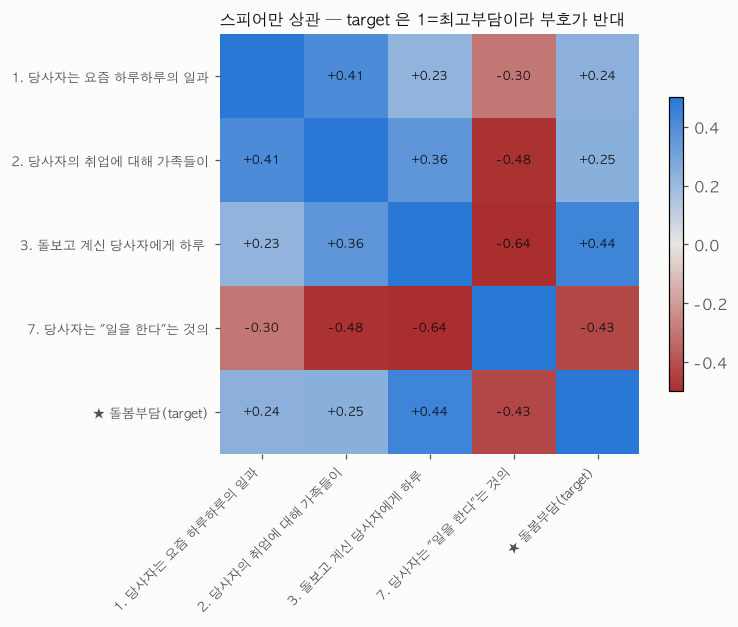

돌봄부담과의 스피어만 상관 (부호 주의):
  +0.241  1. 당사자는 요즘 하루하루의 일과          — 값이 클수록 부담이 적다
  +0.247  2. 당사자의 취업에 대해 가족들이          — 값이 클수록 부담이 적다
  +0.442  3. 돌보고 계신 당사자에게 하루           — 값이 클수록 부담이 적다
  -0.429  7. 당사자는 "일을 한다"는 것의          — 값이 클수록 부담이 크다


In [7]:
ORD = [f for f in F if meta.loc[f,'var_scale'] == 'ordinal']
print('순서형 문항 :', [short[f] for f in ORD], '\n')
sub = df[ORD + ['care_burden']].dropna()
rho, _ = spearmanr(sub)
S = pd.DataFrame(rho, index=[short[c] for c in sub.columns], columns=[short[c] for c in sub.columns])
display(S.round(3))

div = LinearSegmentedColormap.from_list('div', ['#a92e2d','#e8e6e1','#2a78d6'])
fig, ax = plt.subplots(figsize=(7.4, 5.8))
im = ax.imshow(S.values, cmap=div, vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(S))); ax.set_xticklabels(S.columns, rotation=45, ha='right', fontsize=8.4)
ax.set_yticks(range(len(S))); ax.set_yticklabels(S.index, fontsize=8.4)
for i in range(len(S)):
    for j in range(len(S)):
        if i != j:
            ax.annotate(f'{S.values[i,j]:+.2f}', (j,i), ha='center', va='center', fontsize=8, color=INK1)
ax.set_title('스피어만 상관 — target 은 1=최고부담이라 부호가 반대', loc='left', fontsize=10.5)
fig.colorbar(im, ax=ax, shrink=0.7)
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()

print('돌봄부담과의 스피어만 상관 (부호 주의):')
for c in ORD:
    r = S.loc[short[c], short['care_burden']]
    print(f"  {r:+.3f}  {short[c]:28s} — {'값이 클수록 부담이 적다' if r > 0 else '값이 클수록 부담이 크다'}")

## 8. 모델은 이 문항들을 어떻게 쓰나

`models/model_v1.json` 의 계수를 본다. 원-핫이라 문항 하나가 여러 열을 차지하므로,
**그 열들의 계수 절댓값 평균**을 문항의 크기로 본다.

,문항,원핫 열수,평균 |계수|,Cramer's V,결측률 %
0,3. 돌보고 계신 당사자에게 하루,5,0.327,0.234,0.0
1,"7. 당사자는 ""일을 한다""는 것의",4,0.320,0.270,0.0
2,4. 가구의 생계를 주로 책임지는,8,0.306,0.091,0.0
3,6. 응답하시는 분은 당사자와 어떤,8,0.305,0.070,0.0
4,1. 당사자는 요즘 하루하루의 일과,6,0.298,0.155,0.1
5,2. 당사자의 취업에 대해 가족들이,6,0.293,0.163,0.1
6,5. (일을 그만둔 적이 있다면),16,0.283,0.035,88.2


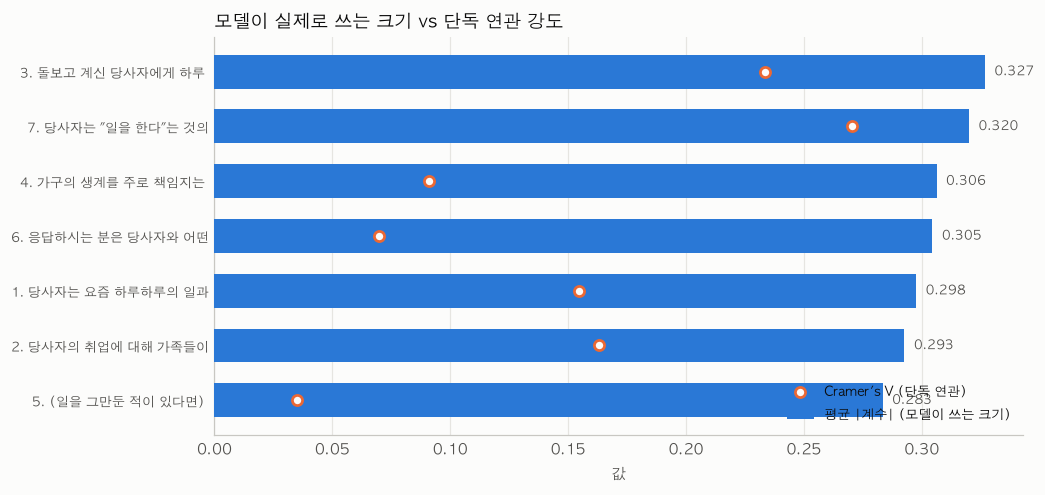

두 값의 순위가 다르면, 그 문항은 다른 문항과 조합될 때 값을 한다는 뜻이다.


In [8]:
coef = np.array(model['coef']); spans = model['spans']
imp = pd.DataFrame({
    '문항': [short[f] for f in F],
    '원핫 열수': [s[1] for s in spans],
    '평균 |계수|': [float(np.abs(coef[:, s[0]:s[0]+s[1]]).mean()) for s in spans],
    "Cramer's V": [V.loc[f,'care_burden'] for f in F],
    '결측률 %': [float(miss[f]) for f in F],
}).sort_values('평균 |계수|', ascending=False)
display(imp.round(3).reset_index(drop=True))

d2 = imp.sort_values('평균 |계수|'); yp = np.arange(len(d2))
fig, ax = plt.subplots(figsize=(9.6, 4.6)); style(ax, grid='x')
ax.barh(yp, d2['평균 |계수|'], height=0.62, color=CAT1, zorder=3, label='평균 |계수| (모델이 쓰는 크기)')
ax.scatter(d2["Cramer's V"], yp, s=44, facecolor=SURFACE, edgecolor=CAT2, lw=1.8, zorder=5,
           label="Cramer's V (단독 연관)")
for i, v in enumerate(d2['평균 |계수|']):
    ax.annotate(f'{v:.3f}', (v+0.004, i), va='center', fontsize=8.4, color=INK2)
ax.set_yticks(yp); ax.set_yticklabels(d2['문항'], fontsize=8.8)
ax.set_xlabel('값')
ax.set_title('모델이 실제로 쓰는 크기 vs 단독 연관 강도', loc='left')
ax.legend(frameon=False, fontsize=8.8, loc='lower right')
fig.tight_layout(); plt.show()
print('두 값의 순위가 다르면, 그 문항은 다른 문항과 조합될 때 값을 한다는 뜻이다.')

---

## 정리

| 무엇을 봤나 | 어디에 쓰이나 |
|---|---|
| 응답 분포·결측률 | 한쪽으로 쏠린 문항, "해당 없음"이 많은 문항 찾기 |
| 선택지별 고부담 비율 | 어느 문항이 부담을 실제로 가르는지 |
| Cramér's V 7×7 | **문항끼리 겹치는지** — 겹치면 하나는 줄일 수 있다 |
| 스피어만 (순서형) | 관계의 **방향**까지 |
| 계수 vs 단독 연관 | 조합에서만 값을 하는 문항 구분 |

## 읽을 때 주의

- **`care_burden` 은 1이 최고부담이다.** 평균이나 상관 부호를 반대로 읽기 쉽다.
  이 노트북은 헷갈림을 줄이려고 **"고부담군(1~2) 비율"** 을 주로 썼다 — 이 값은 클수록 부담이 크다.
- **결측은 누락이 아니다.** 분기 문항의 "해당 없음"이며 그 자체가 정보다.
- **상관은 인과가 아니다.** 일부 변수는 부담의 원인이 아니라 결과에 가깝다.

## 이 노트북이 하지 않은 것

- DB 에 쓰지 않았다 · `models/` 를 건드리지 않았다 · test 602건을 쓰지 않았다